# Greece Day-Ahead Electricity Price Forecasting
## Rolling-Origin Cross-Validation Evaluation

**Classifier**: AutoGluon stacked ensemble (5-fold bagging + L2 stacking)  
**Metric**: Precision(UP) = Precision on High+Spike classes  
**Evaluation**: Expanding-window rolling-origin CV — 3 independent train/test origins  
**Threshold**: P(High) + P(Spike) ≥ 0.65 → predict UP  

---

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from autogluon.tabular import TabularPredictor
from src.config import ROLLING_ORIGINS, MODELS_DIR, AG_LABEL, WF_PROD_THRESHOLD
from src.evaluation import (
    evaluate_rolling_origins,
    _load_test_set_origin,
    plot_confusion_matrix_both,
    plot_feature_importance,
)

print('Setup complete')

Setup complete


---
## 1. Load Rolling-Origin Models

Three models trained on expanding windows — each tested on a full year unseen during training.

In [2]:
origins = []
for name, train_end, val_end, test_end in ROLLING_ORIGINS:
    predictor = TabularPredictor.load(str(MODELS_DIR / f"day_ahead_{name}"))
    test_df   = _load_test_set_origin(val_end, test_end)
    origins.append({"name": name, "predictor": predictor, "test_df": test_df})
    n_up = test_df[AG_LABEL].isin(["High", "Spike"]).sum()
    print(f"Origin {name}: {len(test_df)} test days | {n_up} true UP days ({n_up/len(test_df)*100:.1f}%)")

Origin 2023: 365 test days | 56 true UP days (15.3%)


Origin 2024: 354 test days | 33 true UP days (9.3%)


Origin 2025: 364 test days | 26 true UP days (7.1%)


---
## 2. Rolling-Origin Evaluation

Computes Precision(UP), Recall(UP), and MCC for each origin at threshold 0.65,
with per-month breakdown and threshold calibration curves.


=== Rolling Origin Evaluation ===
Threshold : 0.65
Precision(UP): 0.616  |  MCC: 0.363  |  Std: 0.333
Verdict   : READY (UNSTABLE — high variance across origins)

       precision_up         recall_up             mcc        
               mean     std      mean     std    mean     std
origin                                                       
2023         0.1437  0.3211    0.2500  0.4523 -0.0040  0.0138
2024         0.1667  0.3892    0.0232  0.0554  0.0547  0.1292
2025         0.1149  0.2133    0.1111  0.2051  0.0704  0.1324


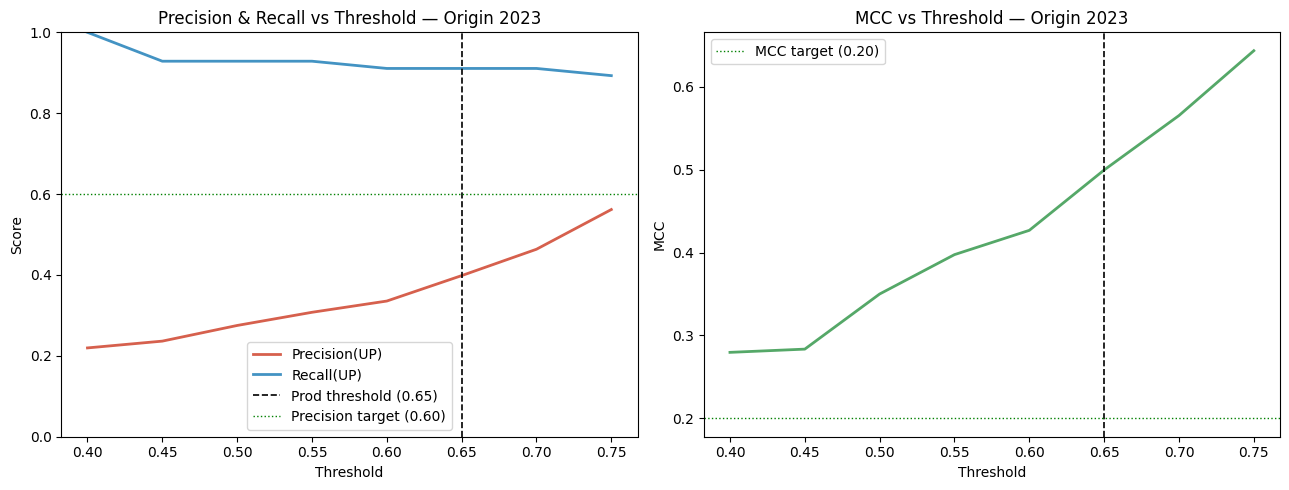

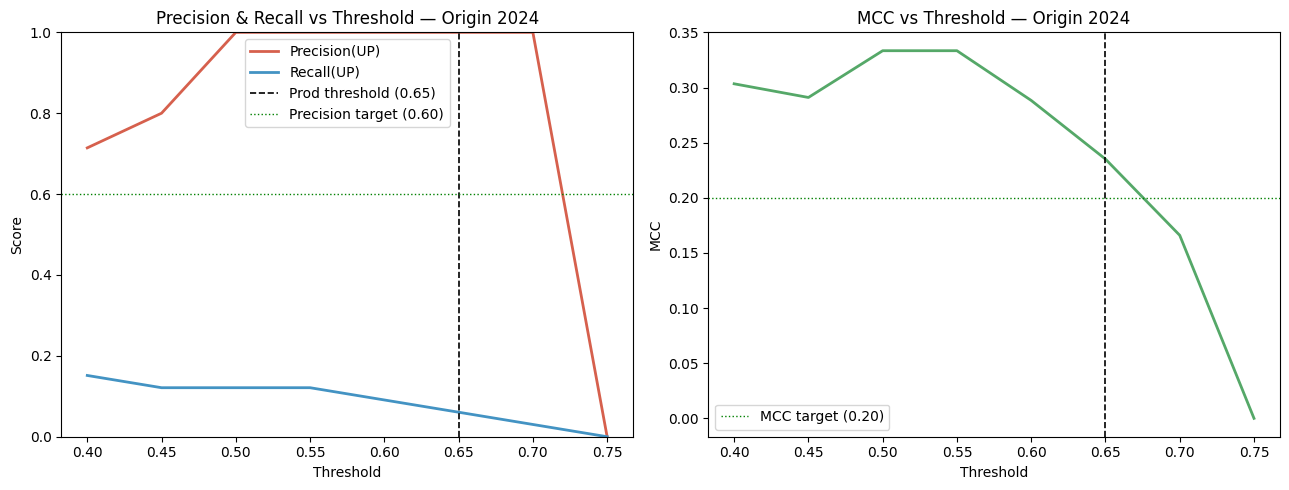

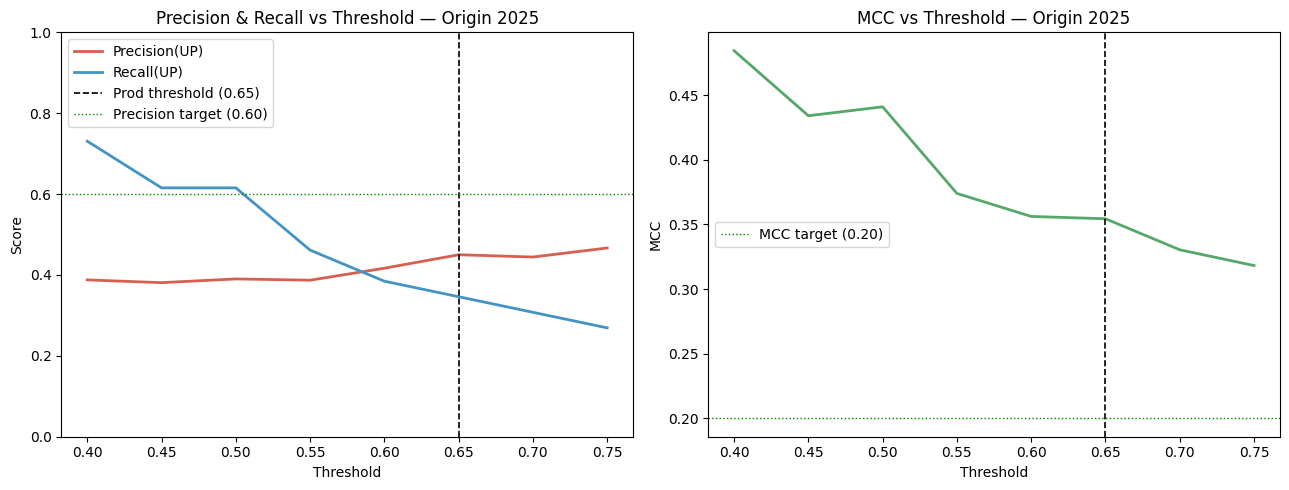

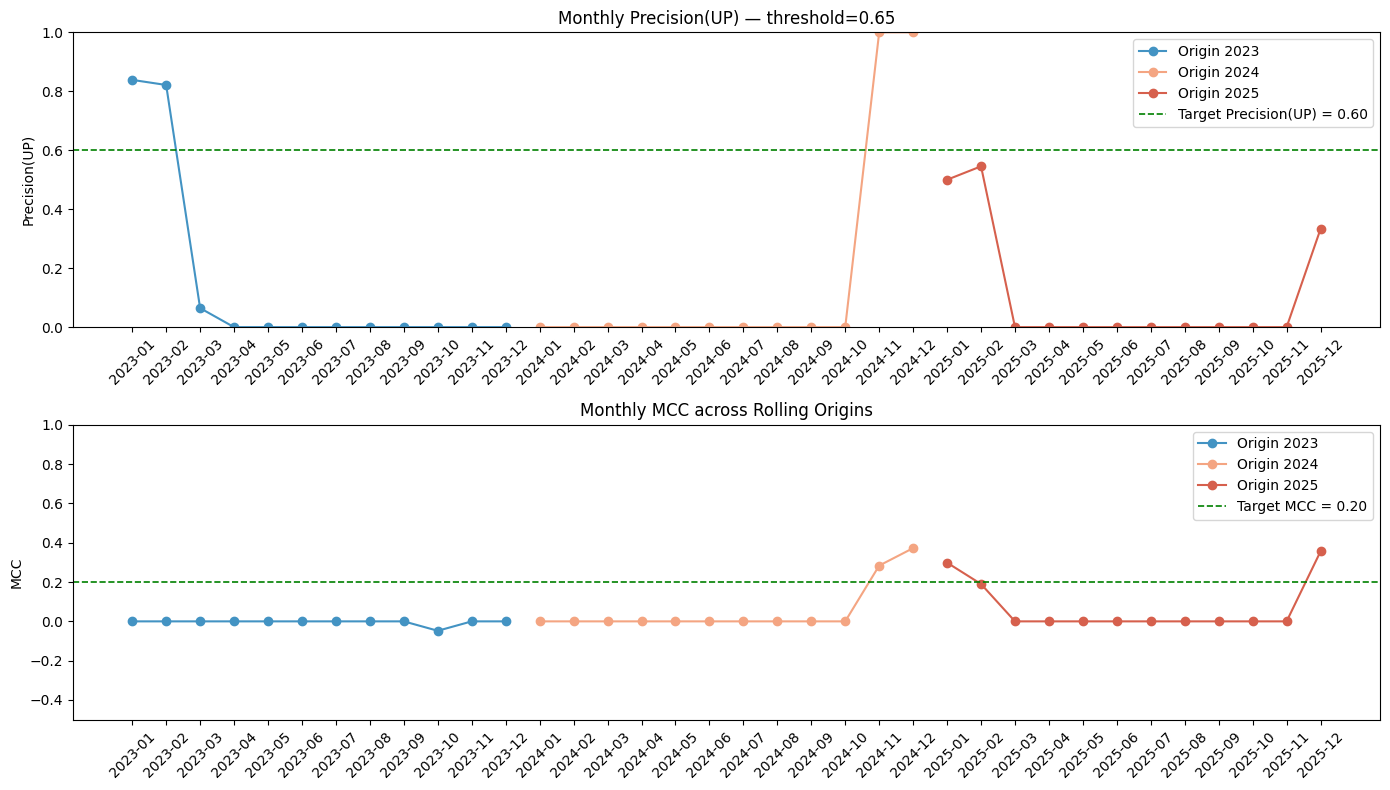

In [3]:
results = evaluate_rolling_origins(origins)

### Per-Origin Summary (mean ± std across 12 monthly windows)

In [4]:
results["origin_summary"].style     .format("{:.3f}")     .background_gradient(cmap="RdYlGn", subset=[("precision_up", "mean")], vmin=0, vmax=1)     .set_caption(f"Rolling-Origin Metrics — threshold={WF_PROD_THRESHOLD}")

### Final Verdict

In [5]:
o = results["overall"]
print(f"Mean Precision(UP) : {o['mean_precision_up']:.3f}  (target >= 0.60)")
print(f"Mean MCC           : {o['mean_mcc']:.3f}  (target >= 0.20)")
print(f"Std Precision(UP)  : {o['std_precision_up']:.3f}  (> 0.15 = UNSTABLE)")
print(f"Production threshold: {o['prod_threshold']}")
print()
print(f"VERDICT: {o['verdict']}")

Mean Precision(UP) : 0.616  (target >= 0.60)
Mean MCC           : 0.363  (target >= 0.20)
Std Precision(UP)  : 0.333  (> 0.15 = UNSTABLE)
Production threshold: 0.65

VERDICT: READY (UNSTABLE — high variance across origins)


---
## 3. Monthly Precision(UP) and MCC across Origins

Each point is one calendar month. Lines represent the three rolling origins.
The green dashed line marks the production target.

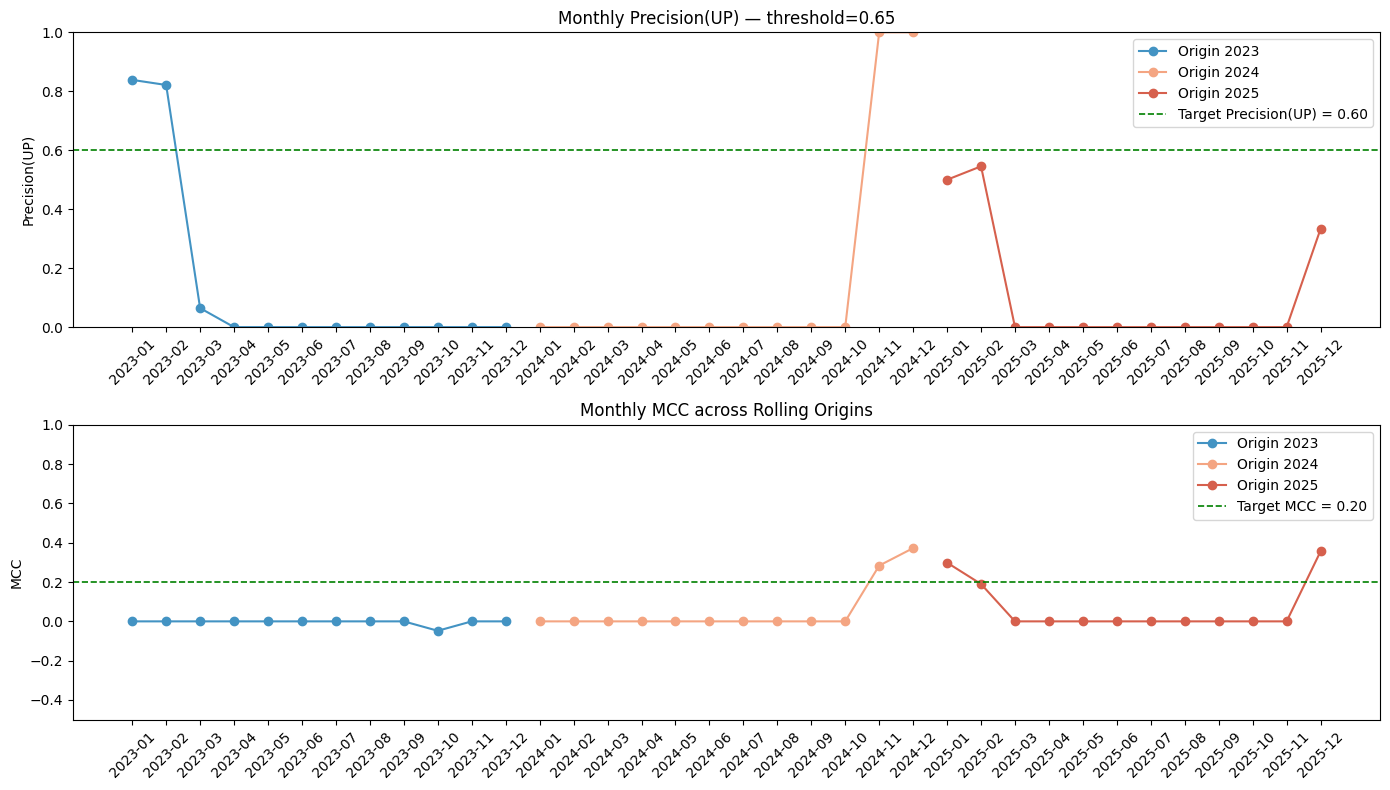

In [6]:
results["results_fig"]

---
## 4. Threshold Calibration

Shows how Precision(UP) and Recall(UP) trade off as the decision threshold varies (0.40 → 0.75).
The vertical dashed line marks the chosen production threshold (0.65).

In [7]:
for name in ["2023", "2024", "2025"]:
    fig = results["threshold_figs"][name]
    plt.figure(fig.number)
    plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

---
## 5. Threshold Calibration Tables

Full Precision / Recall / MCC at each threshold for each origin.

In [8]:
for name, sweep in results["threshold_sweeps"].items():
    display(
        sweep[["precision_up","recall_up","mcc","n_predicted_up","n_true_up"]]
        .style.format("{:.3f}", subset=["precision_up","recall_up","mcc"])
        .format("{:d}", subset=["n_predicted_up","n_true_up"])
        .background_gradient(cmap="RdYlGn", subset=["precision_up","mcc"], vmin=0, vmax=1)
        .set_caption(f"Origin {name} — threshold sweep")
    )

,precision_up,recall_up,mcc,n_predicted_up,n_true_up
threshold,,,,,
0.400000,0.220,1.000,0.280,255,56
0.450000,0.236,0.929,0.283,220,56
0.500000,0.275,0.929,0.350,189,56
0.550000,0.308,0.929,0.398,169,56
0.600000,0.336,0.911,0.427,152,56
0.650000,0.398,0.911,0.500,128,56
0.700000,0.464,0.911,0.565,110,56
0.750000,0.562,0.893,0.643,89,56


,precision_up,recall_up,mcc,n_predicted_up,n_true_up
threshold,,,,,
0.400000,0.714,0.151,0.303,7,33
0.450000,0.800,0.121,0.291,5,33
0.500000,1.000,0.121,0.333,4,33
0.550000,1.000,0.121,0.333,4,33
0.600000,1.000,0.091,0.288,3,33
0.650000,1.000,0.061,0.235,2,33
0.700000,1.000,0.030,0.166,1,33
0.750000,0.000,0.000,0.000,0,33


,precision_up,recall_up,mcc,n_predicted_up,n_true_up
threshold,,,,,
0.400000,0.388,0.731,0.484,49,26
0.450000,0.381,0.615,0.434,42,26
0.500000,0.390,0.615,0.441,41,26
0.550000,0.387,0.462,0.374,31,26
0.600000,0.417,0.385,0.356,24,26
0.650000,0.450,0.346,0.354,20,26
0.700000,0.444,0.308,0.330,18,26
0.750000,0.467,0.269,0.318,15,26


---
## 6. Confusion Matrices per Origin

Row = Actual class, Column = Predicted class. Left: absolute counts. Right: row-normalised recall.

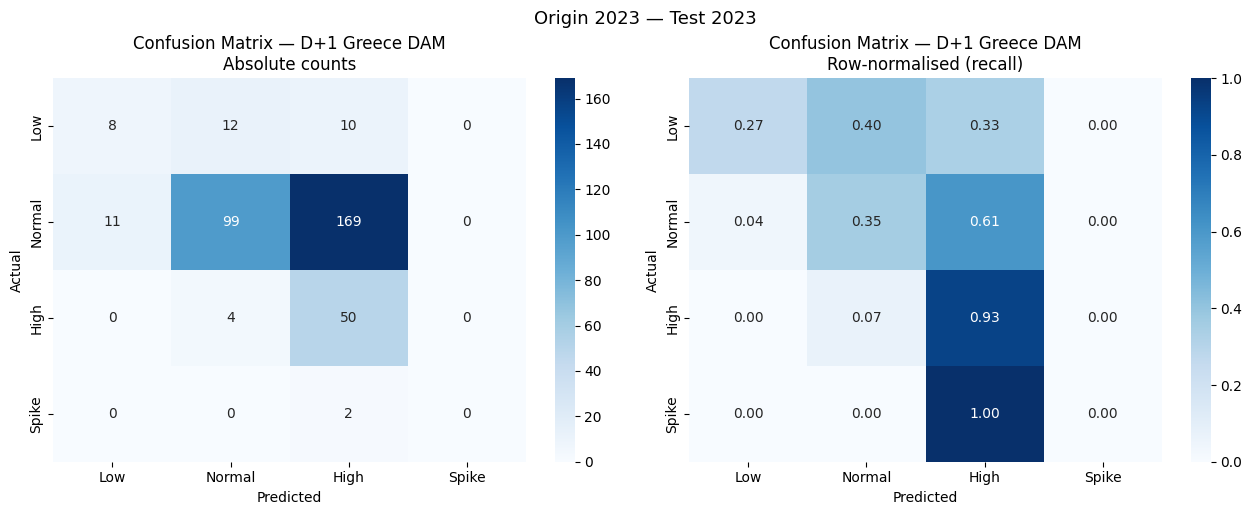

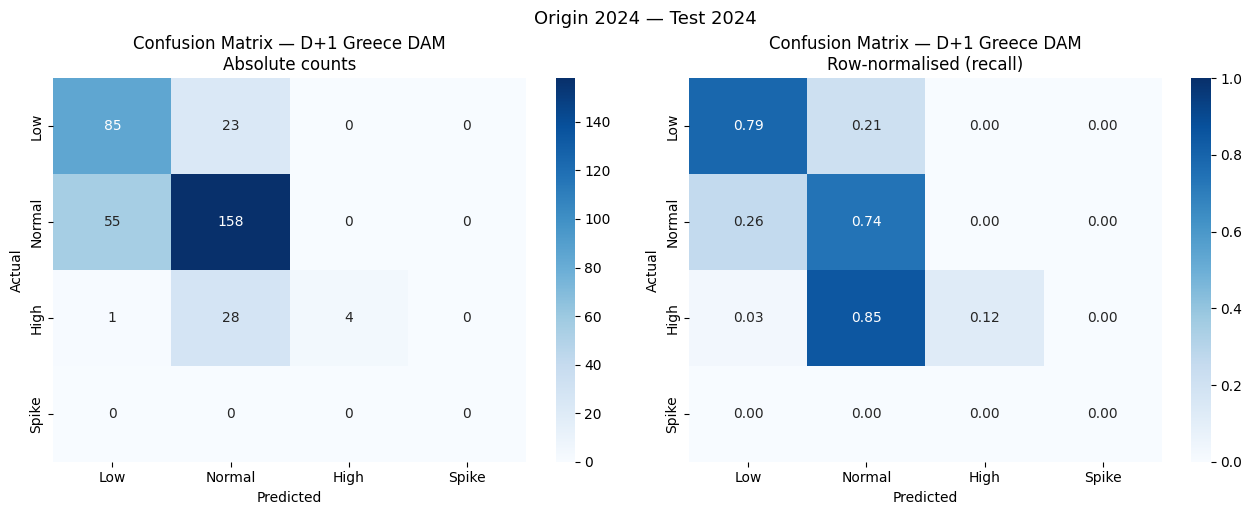

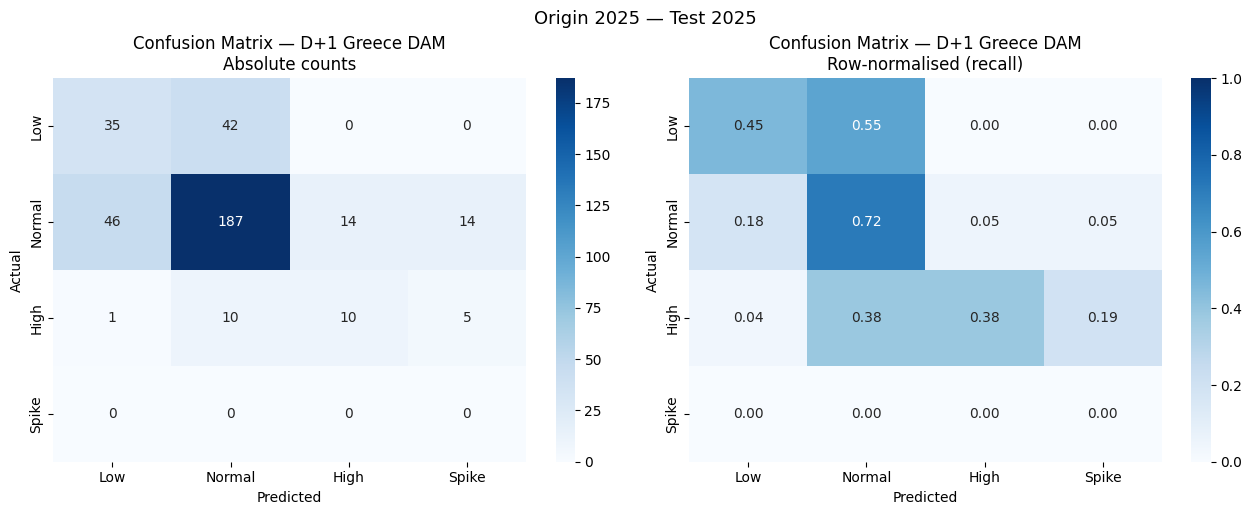

In [9]:
for origin in origins:
    name    = origin["name"]
    test_df = origin["test_df"]
    y_true  = test_df[AG_LABEL]
    y_pred  = origin["predictor"].predict(test_df.drop(columns=[AG_LABEL]))
    fig = plot_confusion_matrix_both(y_true, y_pred)
    fig.suptitle(f"Origin {name} — Test {name}", y=1.02, fontsize=13)
    plt.show()

---
## 7. Feature Importance

Permutation feature importance on the Origin 2025 model (most recent training window).
Higher importance = larger drop in balanced_accuracy when feature is shuffled.

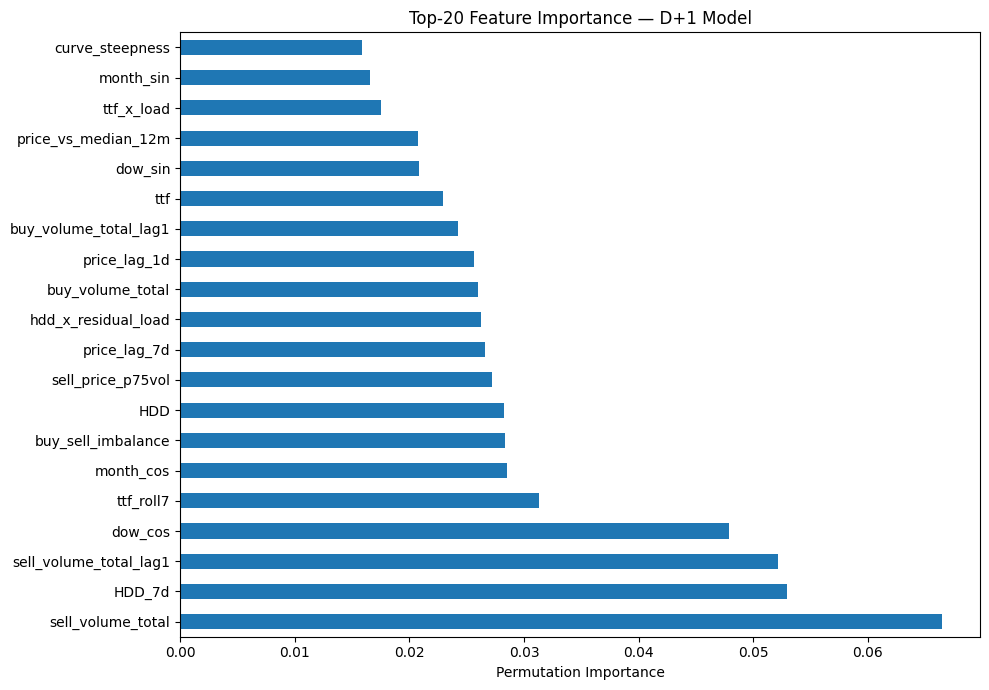

In [10]:
origin_2025 = next(o for o in origins if o["name"] == "2025")
fig = plot_feature_importance(
    origin_2025["predictor"],
    origin_2025["test_df"],
    top_n=20,
)
plt.show()

---
## 8. Per-Origin Monthly Detail

Full monthly breakdown — Precision(UP), Recall(UP), MCC, and prediction counts.

In [11]:
fd = results["fold_results"]
for name, grp in fd.groupby("origin"):
    display(
        grp[["month","n_days","n_true_up","n_predicted_up","precision_up","recall_up","mcc"]]
        .set_index("month")
        .style.format("{:.3f}", subset=["precision_up","recall_up","mcc"])
        .background_gradient(cmap="RdYlGn", subset=["precision_up","mcc"], vmin=0, vmax=1)
        .set_caption(f"Origin {name} — monthly breakdown at threshold {WF_PROD_THRESHOLD}")
    )

,n_days,n_true_up,n_predicted_up,precision_up,recall_up,mcc
month,,,,,,
2023-01,31,26,31,0.839,1.000,0.000
2023-02,28,23,28,0.821,1.000,0.000
2023-03,31,2,31,0.065,1.000,0.000
2023-04,30,0,23,0.000,0.000,0.000
2023-05,31,0,1,0.000,0.000,0.000
2023-06,30,0,0,0.000,0.000,0.000
2023-07,31,0,0,0.000,0.000,0.000
2023-08,31,4,0,0.000,0.000,0.000
2023-09,30,0,0,0.000,0.000,0.000


,n_days,n_true_up,n_predicted_up,precision_up,recall_up,mcc
month,,,,,,
2024-01,31,0,0,0.000,0.000,0.000
2024-02,29,0,0,0.000,0.000,0.000
2024-03,31,0,0,0.000,0.000,0.000
2024-04,30,0,0,0.000,0.000,0.000
2024-05,31,0,0,0.000,0.000,0.000
2024-06,26,0,0,0.000,0.000,0.000
2024-07,23,10,0,0.000,0.000,0.000
2024-08,31,4,0,0.000,0.000,0.000
2024-09,30,4,0,0.000,0.000,0.000


,n_days,n_true_up,n_predicted_up,precision_up,recall_up,mcc
month,,,,,,
2025-01,31,6,4,0.500,0.333,0.299
2025-02,28,12,11,0.545,0.500,0.190
2025-03,31,0,0,0.000,0.000,0.000
2025-04,30,0,0,0.000,0.000,0.000
2025-05,31,1,0,0.000,0.000,0.000
2025-06,30,0,0,0.000,0.000,0.000
2025-07,31,0,0,0.000,0.000,0.000
2025-08,31,0,0,0.000,0.000,0.000
2025-09,30,0,0,0.000,0.000,0.000
